In [3]:
# =========================
# 1. IMPORT VÀ TẢI DỮ LIỆU
# =========================

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.optim import SGD, Adam

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

data_folder = "~/data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

unique_values = tr_targets.unique()

print("tr_images & tr_targets:")
print("X -", tr_images.shape)
print("Y -", tr_targets.shape)
print("Y - Unique Values:", unique_values)
print("TASK:")
print(len(unique_values), "class Classification")
print("UNIQUE CLASSES:")
print(fmnist.classes)

Device: cpu
tr_images & tr_targets:
X - torch.Size([60000, 28, 28])
Y - torch.Size([60000])
Y - Unique Values: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
TASK:
10 class Classification
UNIQUE CLASSES:
['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


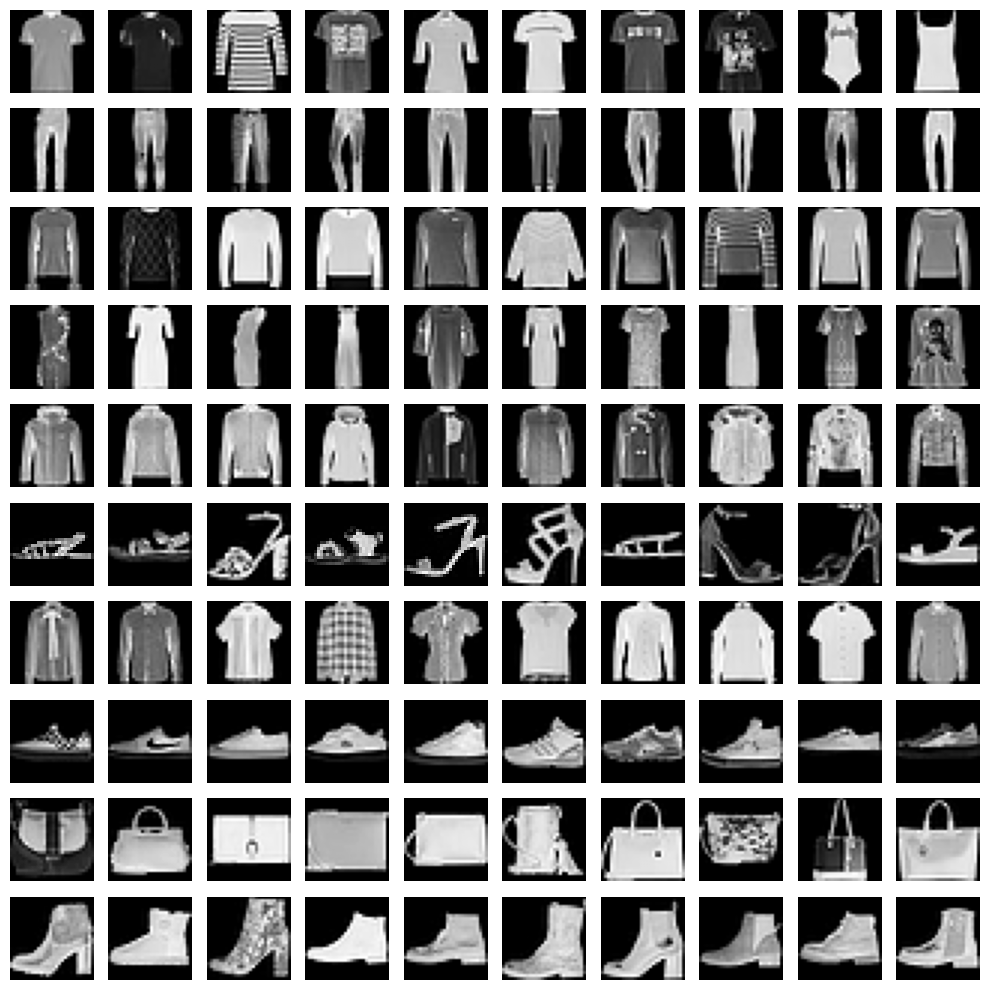

In [4]:
# =========================
# 2. HIỂN THỊ ẢNH MẪU
# =========================

R, C = len(tr_targets.unique()), 10

fig, ax = plt.subplots(R, C, figsize=(10, 10))

for label_class, plot_row in enumerate(ax):
    label_x_rows = np.where(tr_targets == label_class)[0]

    for plot_cell in plot_row:
        plot_cell.grid(False)
        plot_cell.axis("off")

        ix = np.random.choice(label_x_rows)
        x, y = tr_images[ix], tr_targets[ix]

        plot_cell.imshow(x, cmap="gray")

plt.tight_layout()
plt.show()

Epoch: 1
Loss: 38.10653334420522
Accuracy: 0.15036666666666668
Epoch: 2
Loss: 2.2175314030965168
Accuracy: 0.15016666666666667
Epoch: 3
Loss: 2.169426641082764
Accuracy: 0.1615
Epoch: 4
Loss: 2.1770133995691934
Accuracy: 0.15548333333333333
Epoch: 5
Loss: 2.151500236384074
Accuracy: 0.16543333333333332


/tmp/ipykernel_573/505486243.py:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


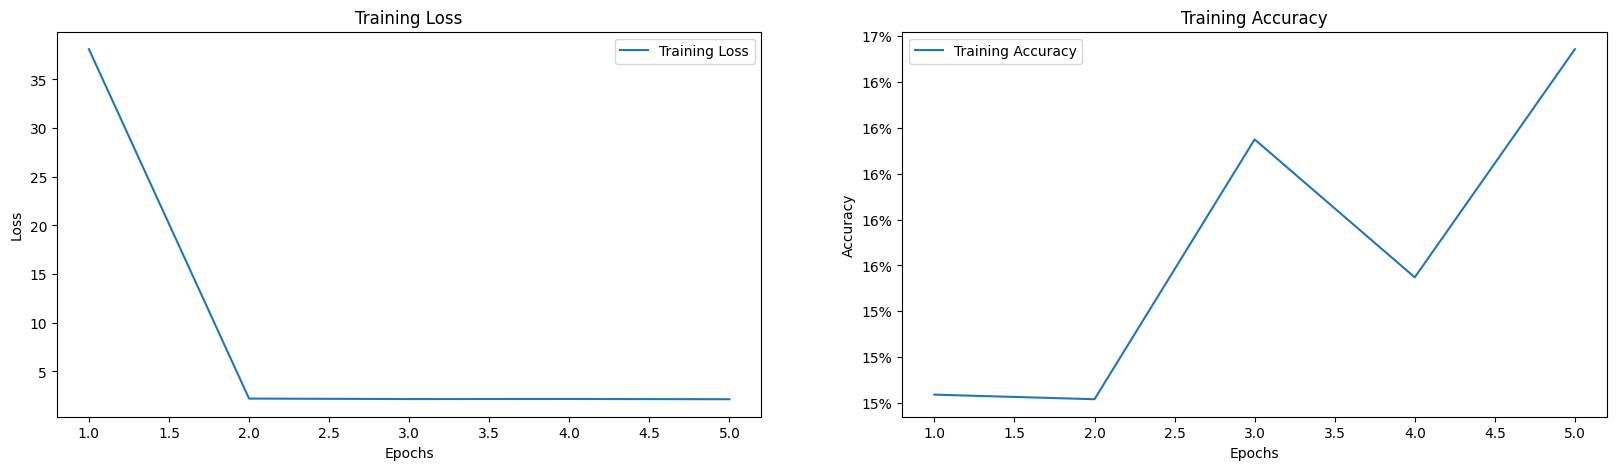

In [5]:
# ======================================================
# 3. HUẤN LUYỆN MẠNG NƠ-RON - CHƯA CHIA ẢNH CHO 255
# ======================================================

class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl


def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)

    return model, loss_fn, optimizer


def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


trn_dl = get_data()
model, loss_fn, optimizer = get_model()

losses, accuracies = [], []

for epoch in range(5):
    print("Epoch:", epoch + 1)

    epoch_losses, epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)

    epoch_loss = np.array(epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)

    epoch_accuracy = np.mean(epoch_accuracies)

    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

    print("Loss:", epoch_loss)
    print("Accuracy:", epoch_accuracy)


epochs = np.arange(5) + 1

plt.figure(figsize=(20, 5))

plt.subplot(121)
plt.title("Training Loss")
plt.plot(epochs, losses, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(122)
plt.title("Training Accuracy")
plt.plot(epochs, accuracies, label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()

plt.show()

Epoch: 1
Train Loss: 0.5384460307121277
Train Accuracy: 0.8405333333333334
Validation Loss: 0.5003703832626343
Validation Accuracy: 0.8264
Epoch: 2
Train Loss: 0.4353004397034645
Train Accuracy: 0.8581
Validation Loss: 0.43587079644203186
Validation Accuracy: 0.8433
Epoch: 3
Train Loss: 0.41144545461734133
Train Accuracy: 0.8650833333333333
Validation Loss: 0.4562995135784149
Validation Accuracy: 0.8474
Epoch: 4
Train Loss: 0.3948774041831493
Train Accuracy: 0.8602333333333333
Validation Loss: 0.45525580644607544
Validation Accuracy: 0.8402
Epoch: 5
Train Loss: 0.3862064421137174
Train Accuracy: 0.8724
Validation Loss: 0.43805304169654846
Validation Accuracy: 0.8447


/tmp/ipykernel_573/4064041715.py:105: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


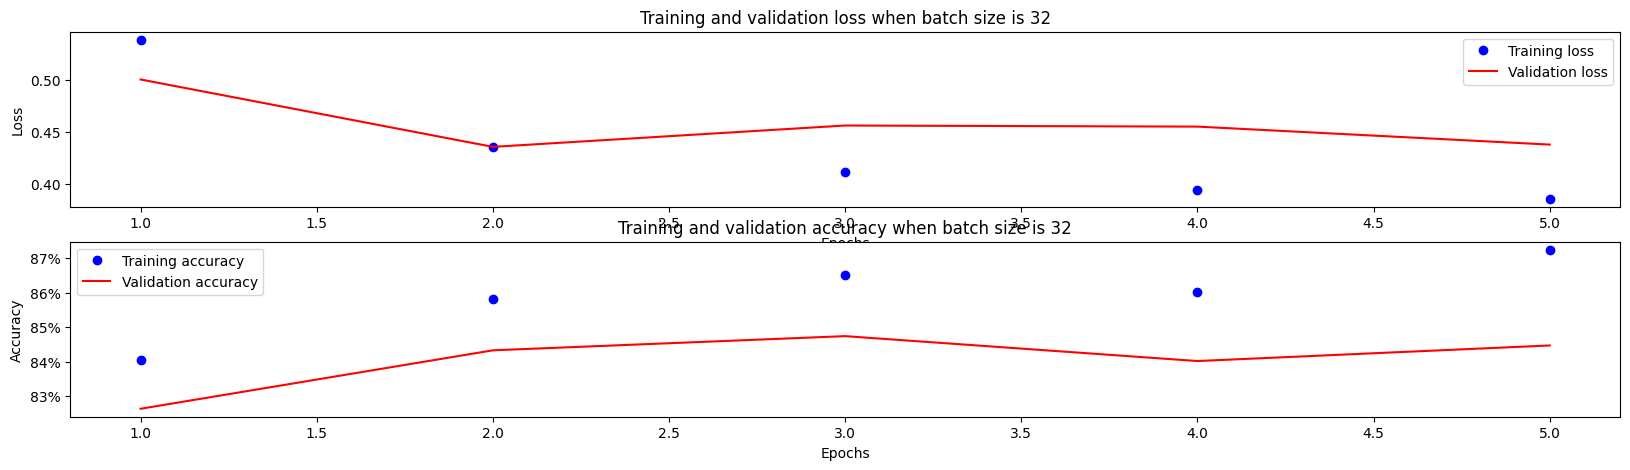

In [6]:
# ======================================================
# 5. THÊM TẬP VALIDATION, DÙNG ADAM, BATCH SIZE = 32
# ======================================================

val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)
val_images = val_fmnist.data
val_targets = val_fmnist.targets
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer
def get_data(batch_size=32):
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=batch_size, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()
@torch.no_grad()
def val_loss(x, y, model):
    model.eval()
    prediction = model(x)
    validation_loss = loss_fn(prediction, y)
    return validation_loss.item()
trn_dl, val_dl = get_data(batch_size=32)
model, loss_fn, optimizer = get_model()
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(5):
    print("Epoch:", epoch + 1)
    train_epoch_losses, train_epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
    val_epoch_accuracy = np.mean(val_is_correct)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

    print("Train Loss:", train_epoch_loss)
    print("Train Accuracy:", train_epoch_accuracy)
    print("Validation Loss:", validation_loss)
    print("Validation Accuracy:", val_epoch_accuracy)
epochs = np.arange(5) + 1
plt.figure(figsize=(20, 5))
plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.title("Training and validation loss when batch size is 32")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)
plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.title("Training and validation accuracy when batch size is 32")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.show()

Device: cpu
Epoch: 1
Train Loss: 4.156199157238007
Train Accuracy: 0.48013333333333336
Validation Loss: 2.399080753326416
Validation Accuracy: 0.4762
----------------------------------------
Epoch: 2
Train Loss: 1.3690757552782695
Train Accuracy: 0.6872833333333334
Validation Loss: 0.8964411020278931
Validation Accuracy: 0.6765
----------------------------------------
Epoch: 3
Train Loss: 0.7530634800593058
Train Accuracy: 0.7515666666666667
Validation Loss: 0.6864233613014221
Validation Accuracy: 0.7405
----------------------------------------
Epoch: 4
Train Loss: 0.6323853532473246
Train Accuracy: 0.7916333333333333
Validation Loss: 0.6141988039016724
Validation Accuracy: 0.7776
----------------------------------------
Epoch: 5
Train Loss: 0.551048199335734
Train Accuracy: 0.8141
Validation Loss: 0.5416244864463806
Validation Accuracy: 0.8037
----------------------------------------


/tmp/ipykernel_573/798374225.py:147: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


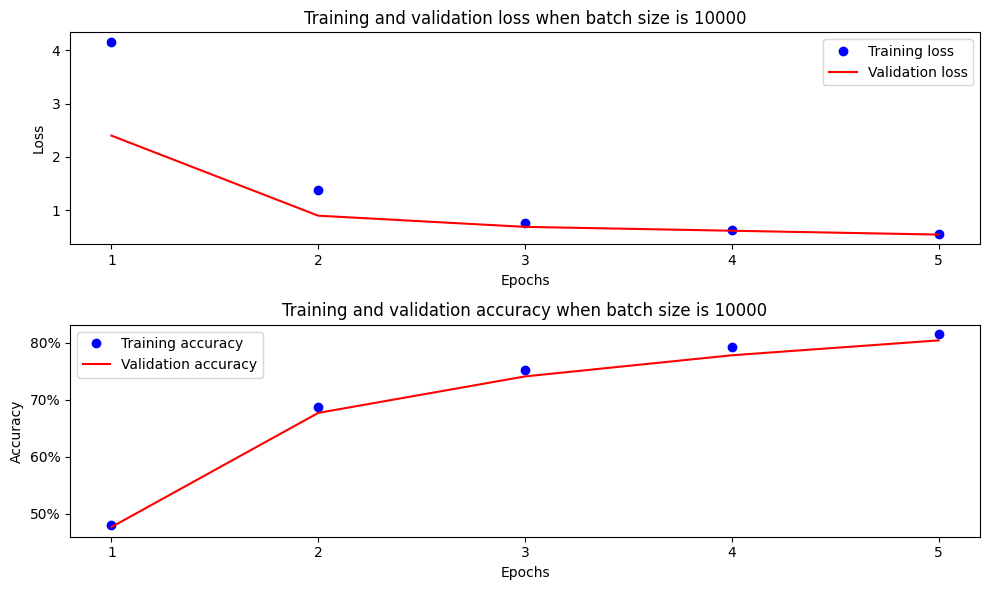

In [7]:
# ================================
# CÂU 6: THAY ĐỔI BATCH SIZE = 10000
# ================================

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Thiết bị chạy
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
# Tải dữ liệu FashionMNIST
data_folder = "~/data/FMNIST"
fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)
tr_images = fmnist.data
tr_targets = fmnist.targets
val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)
val_images = val_fmnist.data
val_targets = val_fmnist.targets
# Tạo Dataset
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)
# Hàm lấy dữ liệu với batch size = 10000
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=10000, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl
# Xây dựng mô hình
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer
# Hàm huấn luyện một batch
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()
# Hàm tính độ chính xác
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()
# Hàm tính loss trên validation
@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()

    prediction = model(x)
    validation_loss = loss_fn(prediction, y)

    return validation_loss.item()


# Gọi DataLoader, model, loss, optimizer
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
# Huấn luyện 5 epoch
for epoch in range(5):
    print("Epoch:", epoch + 1)
    train_epoch_losses = []
    train_epoch_accuracies = []
    # Train
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    # Tính accuracy trên tập train
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    # Validation
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)
    val_epoch_accuracy = np.mean(val_is_correct)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)
    print("Train Loss:", train_epoch_loss)
    print("Train Accuracy:", train_epoch_accuracy)
    print("Validation Loss:", validation_loss)
    print("Validation Accuracy:", val_epoch_accuracy)
    print("-" * 40)
# Vẽ biểu đồ
epochs = np.arange(5) + 1
plt.figure(figsize=(10, 6))
plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss when batch size is 10000")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)
plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy when batch size is 10000")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [8]:
# ================================
# SGD OPTIMIZER
# ================================

from torchvision import datasets
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import SGD, Adam

device = 'cuda' if torch.cuda.is_available() else 'cpu'
data_folder = '~/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)
    def __len__(self):
        return len(self.x)
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl
@torch.no_grad()
def val_loss(x, y, model):
    model.eval()
    prediction = model(x)
    validation_loss = loss_fn(prediction, y)
    return validation_loss.item()
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(10):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
    val_epoch_accuracy = np.mean(val_is_correct)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4
5
6
7
8
9


/tmp/ipykernel_573/3924336097.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


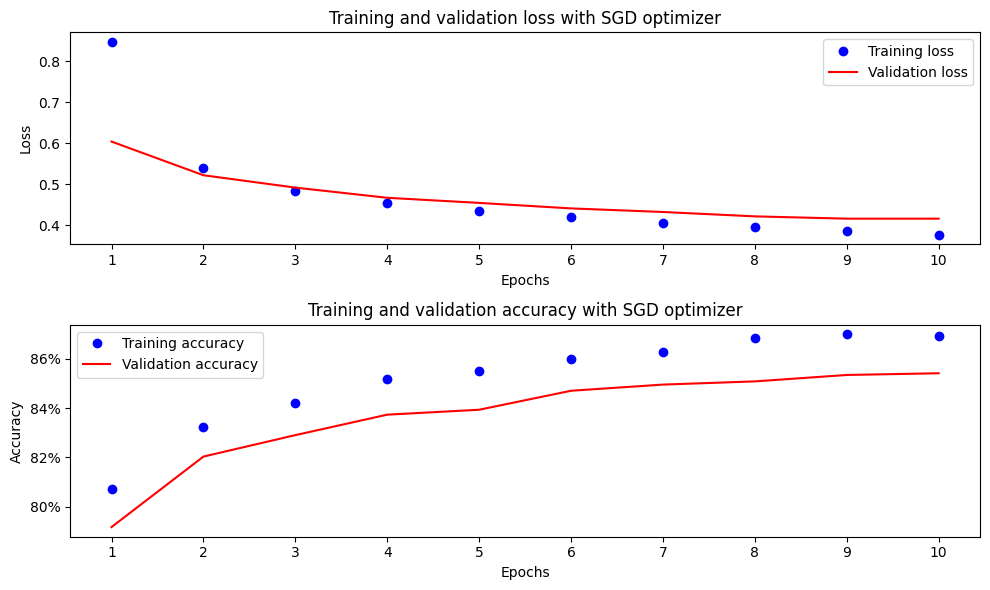

In [9]:
# ================================
# VẼ BIỂU ĐỒ SGD
# ================================

epochs = np.arange(10) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(10, 6))
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with SGD optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [10]:
# ================================
# ADAM OPTIMIZER
# ================================

from torch.optim import SGD, Adam

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(10):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_accuracy = np.mean(train_epoch_accuracies)
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
    val_epoch_accuracy = np.mean(val_is_correct)
    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4
5
6
7
8
9


/tmp/ipykernel_573/492877319.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


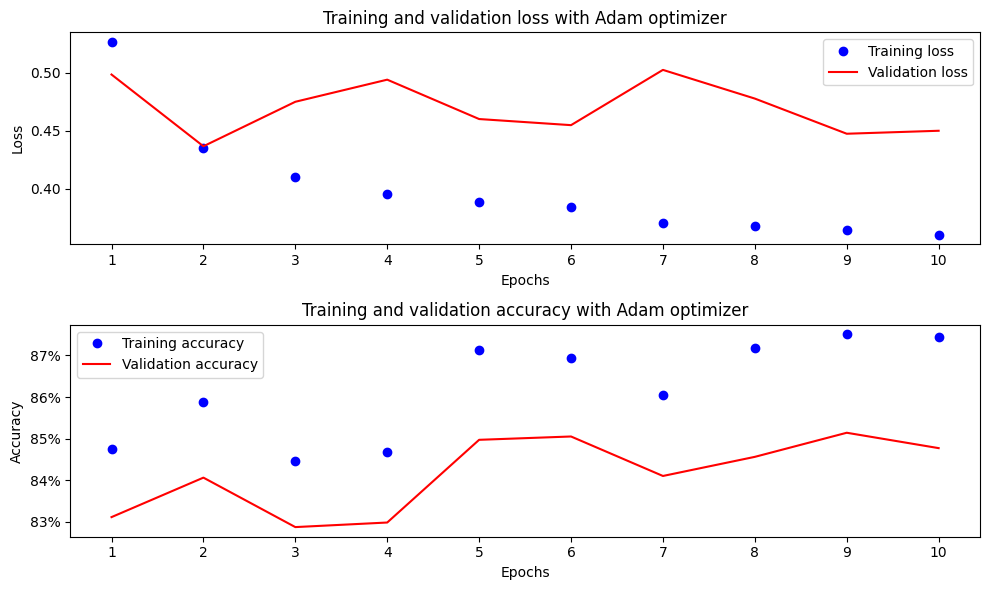

In [11]:
# ================================
# VẼ BIỂU ĐỒ ADAM
# ================================

epochs = np.arange(10) + 1

import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.figure(figsize=(10, 6))
plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with Adam optimizer')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [12]:
# ================================
# HIGH LEARNING RATE - ADAM lr = 0.1
# ================================

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-1)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(10):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4
5
6
7
8
9


/tmp/ipykernel_573/3091116814.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


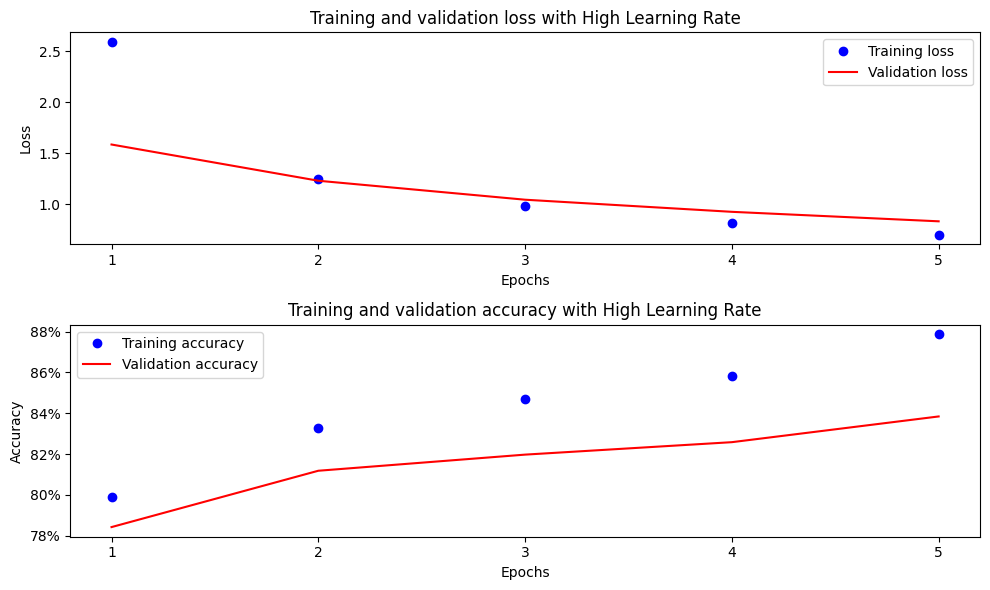

In [30]:
import matplotlib.ticker as mticker

# ================================
# VẼ BIỂU ĐỒ ADAM lr = 0.1
# ================================

epochs = np.arange(len(train_losses)) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with High Learning Rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with High Learning Rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [27]:
# ============================================
# TÁC ĐỘNG CỦA TỐC ĐỘ HỌC - FASHION MNIST
# ============================================

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Tải dữ liệu
data_folder = "~/data/FMNIST"

fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=True
)

tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(
    data_folder,
    download=True,
    train=False
)

val_images = val_fmnist.data
val_targets = val_fmnist.targets


# Dataset có chia tỷ lệ ảnh cho 255
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float() / 255
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


def get_model(lr):
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)

    return model, loss_fn, optimizer


def train_batch(x, y, model, opt, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    opt.step()
    opt.zero_grad()

    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)

    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()

    prediction = model(x)
    validation_loss = loss_fn(prediction, y)

    return validation_loss.item()


def train_model(lr, epochs_count=5):
    trn_dl, val_dl = get_data()
    model, loss_fn, optimizer = get_model(lr)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs_count):
        print("Epoch:", epoch + 1)

        train_epoch_losses = []
        train_epoch_accuracies = []

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            train_epoch_losses.append(batch_loss)

        train_epoch_loss = np.array(train_epoch_losses).mean()

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            is_correct = accuracy(x, y, model)
            train_epoch_accuracies.extend(is_correct)

        train_epoch_accuracy = np.mean(train_epoch_accuracies)

        for ix, batch in enumerate(iter(val_dl)):
            x, y = batch
            val_is_correct = accuracy(x, y, model)
            validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_accuracy)
        val_losses.append(validation_loss)
        val_accuracies.append(val_epoch_accuracy)

        print("Train Loss:", train_epoch_loss)
        print("Train Accuracy:", train_epoch_accuracy)
        print("Validation Loss:", validation_loss)
        print("Validation Accuracy:", val_epoch_accuracy)
        print("-" * 40)

    return train_losses, train_accuracies, val_losses, val_accuracies


def plot_result(train_losses, train_accuracies, val_losses, val_accuracies, lr):
    epochs = np.arange(len(train_losses)) + 1

    plt.figure(figsize=(10, 6))

    plt.subplot(211)
    plt.plot(epochs, train_losses, "bo", label="Training loss")
    plt.plot(epochs, val_losses, "r", label="Validation loss")
    plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
    plt.title(f"Training and validation loss with {lr} learning rate")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(False)

    plt.subplot(212)
    plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
    plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
    plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
    plt.title(f"Training and validation accuracy with {lr} learning rate")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])
    plt.legend()
    plt.grid(False)

    plt.tight_layout()
    plt.show()

Device: cpu


Epoch: 1
Train Loss: 3.294451938311259
Train Accuracy: 0.22366666666666668
Validation Loss: 2.0210444927215576
Validation Accuracy: 0.2225
----------------------------------------
Epoch: 2
Train Loss: 2.064262608210246
Train Accuracy: 0.23606666666666667
Validation Loss: 1.9349591732025146
Validation Accuracy: 0.2364
----------------------------------------
Epoch: 3
Train Loss: 2.221235747083028
Train Accuracy: 0.14526666666666666
Validation Loss: 2.1918580532073975
Validation Accuracy: 0.146
----------------------------------------
Epoch: 4
Train Loss: 2.200100093332926
Train Accuracy: 0.14035
Validation Loss: 2.2124311923980713
Validation Accuracy: 0.1419
----------------------------------------
Epoch: 5
Train Loss: 2.204642597579956
Train Accuracy: 0.14971666666666666
Validation Loss: 2.19655442237854
Validation Accuracy: 0.1503
----------------------------------------


/tmp/ipykernel_573/1376204521.py:186: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


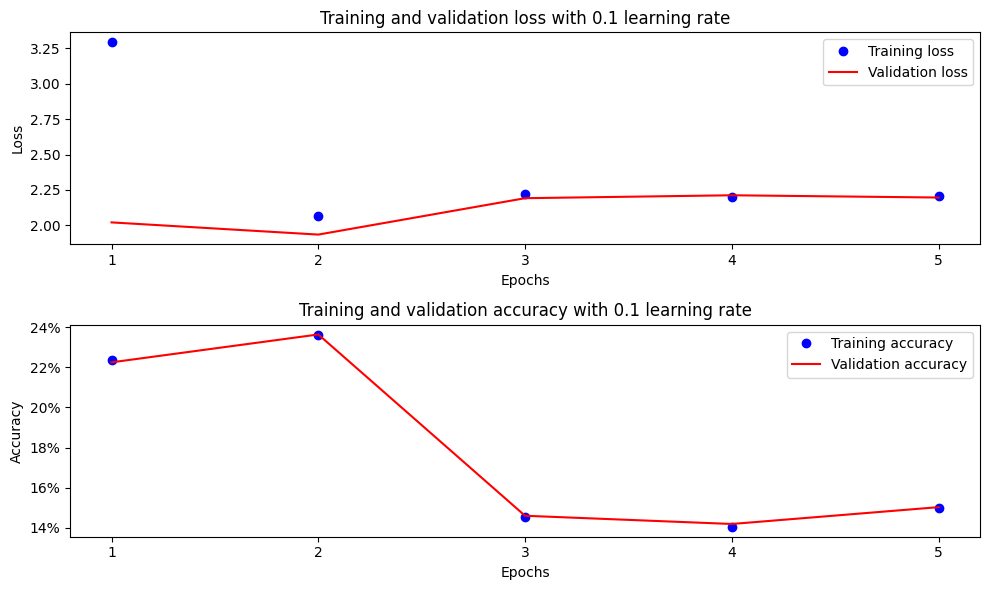

In [14]:
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    lr=1e-1,
    epochs_count=5
)

plot_result(
    train_losses,
    train_accuracies,
    val_losses,
    val_accuracies,
    lr=0.1
)

Epoch: 1
Train Loss: 0.47476726906696953
Train Accuracy: 0.8685666666666667
Validation Loss: 0.4059602916240692
Validation Accuracy: 0.8524
----------------------------------------
Epoch: 2
Train Loss: 0.35725365013480187
Train Accuracy: 0.8822666666666666
Validation Loss: 0.3797142803668976
Validation Accuracy: 0.8642
----------------------------------------
Epoch: 3
Train Loss: 0.31935350756148495
Train Accuracy: 0.8886666666666667
Validation Loss: 0.37195783853530884
Validation Accuracy: 0.866
----------------------------------------
Epoch: 4
Train Loss: 0.29913949449857075
Train Accuracy: 0.9016333333333333
Validation Loss: 0.3452017903327942
Validation Accuracy: 0.8781
----------------------------------------
Epoch: 5
Train Loss: 0.28005082561870415
Train Accuracy: 0.8994666666666666
Validation Loss: 0.3488302528858185
Validation Accuracy: 0.8725
----------------------------------------


/tmp/ipykernel_573/1376204521.py:186: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


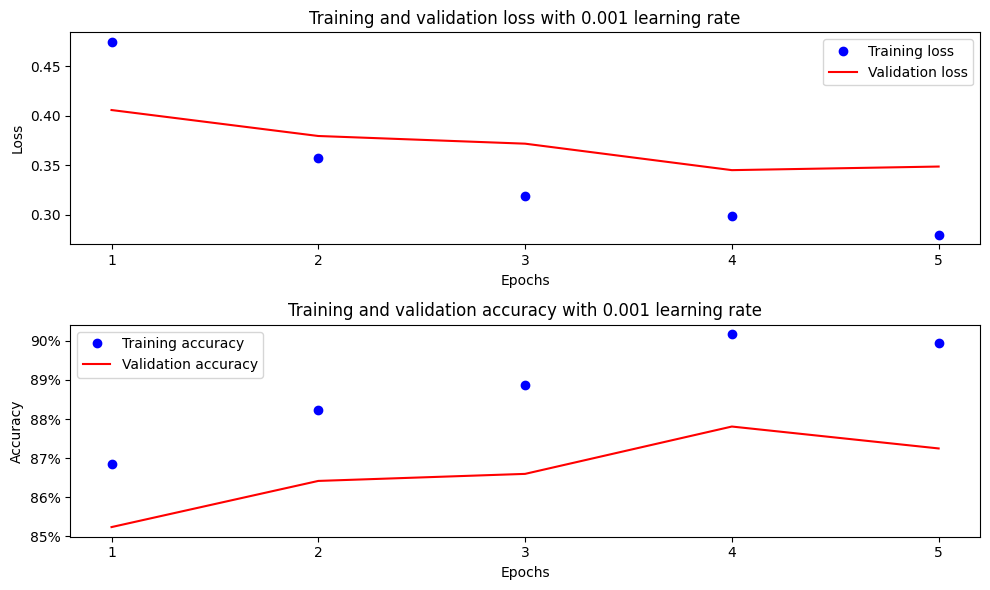

In [15]:
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    lr=1e-3,
    epochs_count=5
)

plot_result(
    train_losses,
    train_accuracies,
    val_losses,
    val_accuracies,
    lr=0.001
)

Epoch: 1
Train Loss: 1.186108647473653
Train Accuracy: 0.7557333333333334
Validation Loss: 0.7951626777648926
Validation Accuracy: 0.7418
----------------------------------------
Epoch: 2
Train Loss: 0.6906851551135381
Train Accuracy: 0.7995666666666666
Validation Loss: 0.6507669687271118
Validation Accuracy: 0.7844
----------------------------------------
Epoch: 3
Train Loss: 0.5923324229240418
Train Accuracy: 0.8154
Validation Loss: 0.5847496390342712
Validation Accuracy: 0.8024
----------------------------------------
Epoch: 4
Train Loss: 0.5424766283273696
Train Accuracy: 0.8271
Validation Loss: 0.5482890605926514
Validation Accuracy: 0.8167
----------------------------------------
Epoch: 5
Train Loss: 0.5110741021076838
Train Accuracy: 0.8342333333333334
Validation Loss: 0.5238932967185974
Validation Accuracy: 0.8232
----------------------------------------


/tmp/ipykernel_573/1376204521.py:186: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(["{:.0f}%".format(x * 100) for x in plt.gca().get_yticks()])


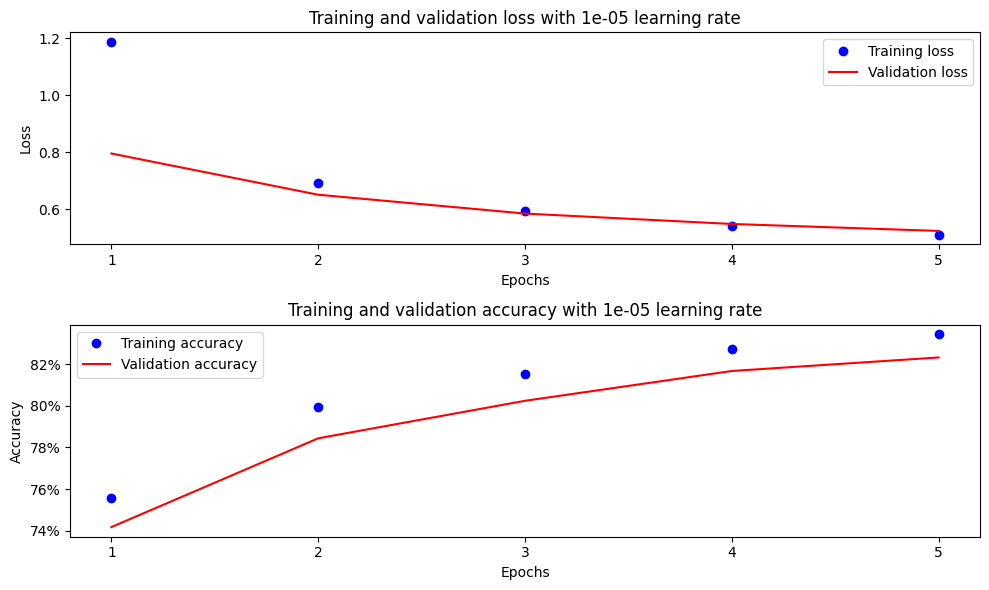

In [16]:
train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    lr=1e-5,
    epochs_count=5
)

plot_result(
    train_losses,
    train_accuracies,
    val_losses,
    val_accuracies,
    lr=0.00001
)

0
1
2
3
4


/tmp/ipykernel_573/170948817.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


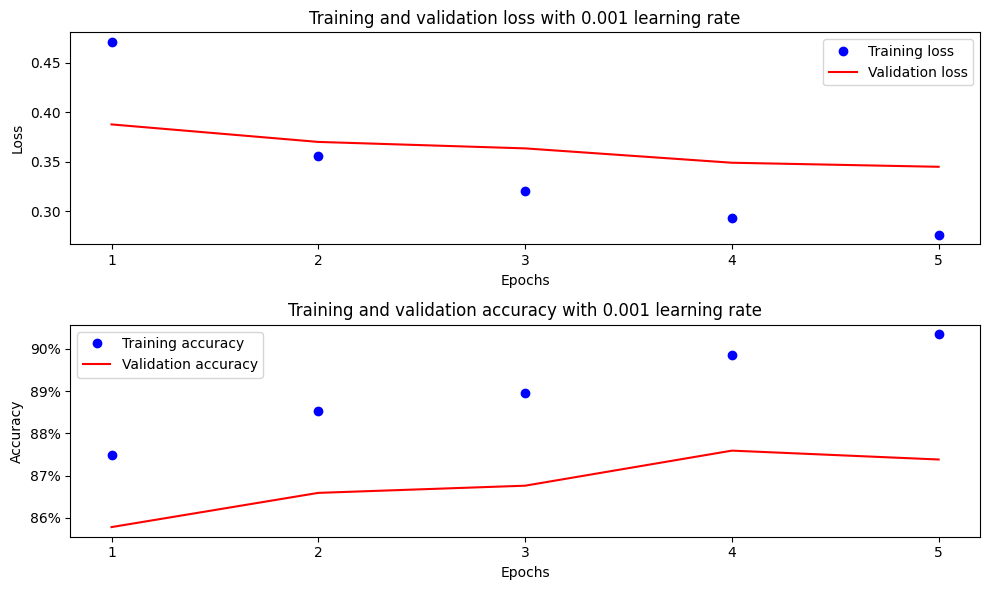

In [17]:
# ================================
# TỐC ĐỘ HỌC TRUNG BÌNH: lr = 0.001
# ================================

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

0
1
2
3
4


/tmp/ipykernel_573/3650037045.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])


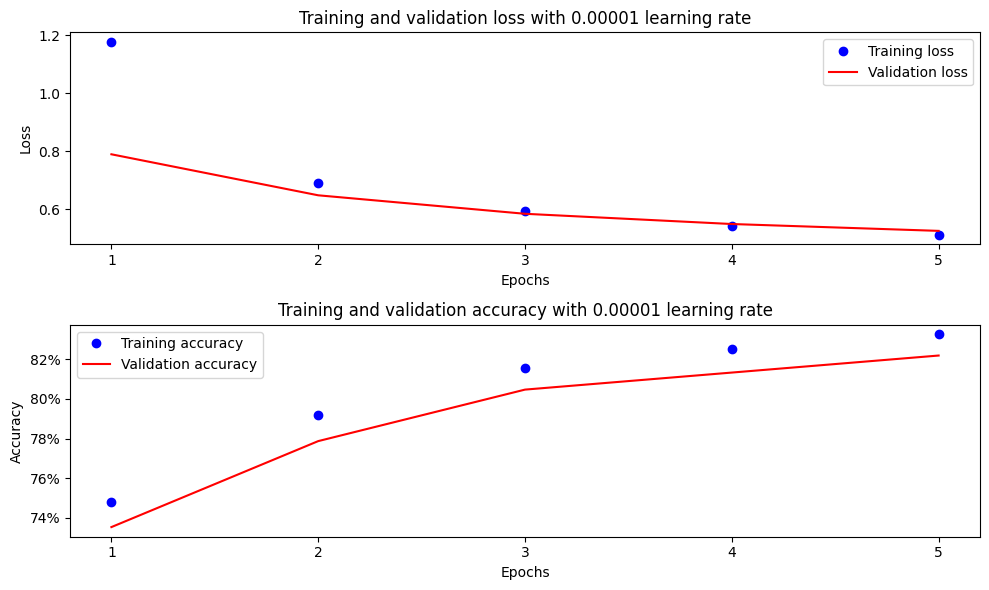

In [18]:
# ================================
# TỐC ĐỘ HỌC THẤP: lr = 0.00001
# ================================

def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-5)

    return model, loss_fn, optimizer


trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(5):
    print(epoch)

    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model, loss_fn)

    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)


epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with 0.00001 learning rate')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()])
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

In [19]:
# ============================================================
# So sánh learning rate = 0.1, 0.001, 0.00001
# Dữ liệu đã chia /255
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam


def get_model_by_lr(lr):
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)

    return model, loss_fn, optimizer


def train_and_get_model(lr, epochs_count=5):
    trn_dl, val_dl = get_data()
    model, loss_fn, optimizer = get_model_by_lr(lr)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs_count):
        print("Learning rate:", lr, "- Epoch:", epoch)

        train_epoch_losses, train_epoch_accuracies = [], []

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            train_epoch_losses.append(batch_loss)

        train_epoch_loss = np.array(train_epoch_losses).mean()

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            is_correct = accuracy(x, y, model)
            train_epoch_accuracies.extend(is_correct)

        train_epoch_accuracy = np.mean(train_epoch_accuracies)

        for ix, batch in enumerate(iter(val_dl)):
            x, y = batch
            val_is_correct = accuracy(x, y, model)
            validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_accuracy)
        val_losses.append(validation_loss)
        val_accuracies.append(val_epoch_accuracy)

    return model

model_lr_01 = train_and_get_model(lr=1e-1, epochs_count=5)
model_lr_0001 = train_and_get_model(lr=1e-3, epochs_count=5)
model_lr_000001 = train_and_get_model(lr=1e-5, epochs_count=5)

Learning rate: 0.1 - Epoch: 0
Learning rate: 0.1 - Epoch: 1
Learning rate: 0.1 - Epoch: 2
Learning rate: 0.1 - Epoch: 3
Learning rate: 0.1 - Epoch: 4
Learning rate: 0.001 - Epoch: 0
Learning rate: 0.001 - Epoch: 1
Learning rate: 0.001 - Epoch: 2
Learning rate: 0.001 - Epoch: 3
Learning rate: 0.001 - Epoch: 4
Learning rate: 1e-05 - Epoch: 0
Learning rate: 1e-05 - Epoch: 1
Learning rate: 1e-05 - Epoch: 2
Learning rate: 1e-05 - Epoch: 3
Learning rate: 1e-05 - Epoch: 4


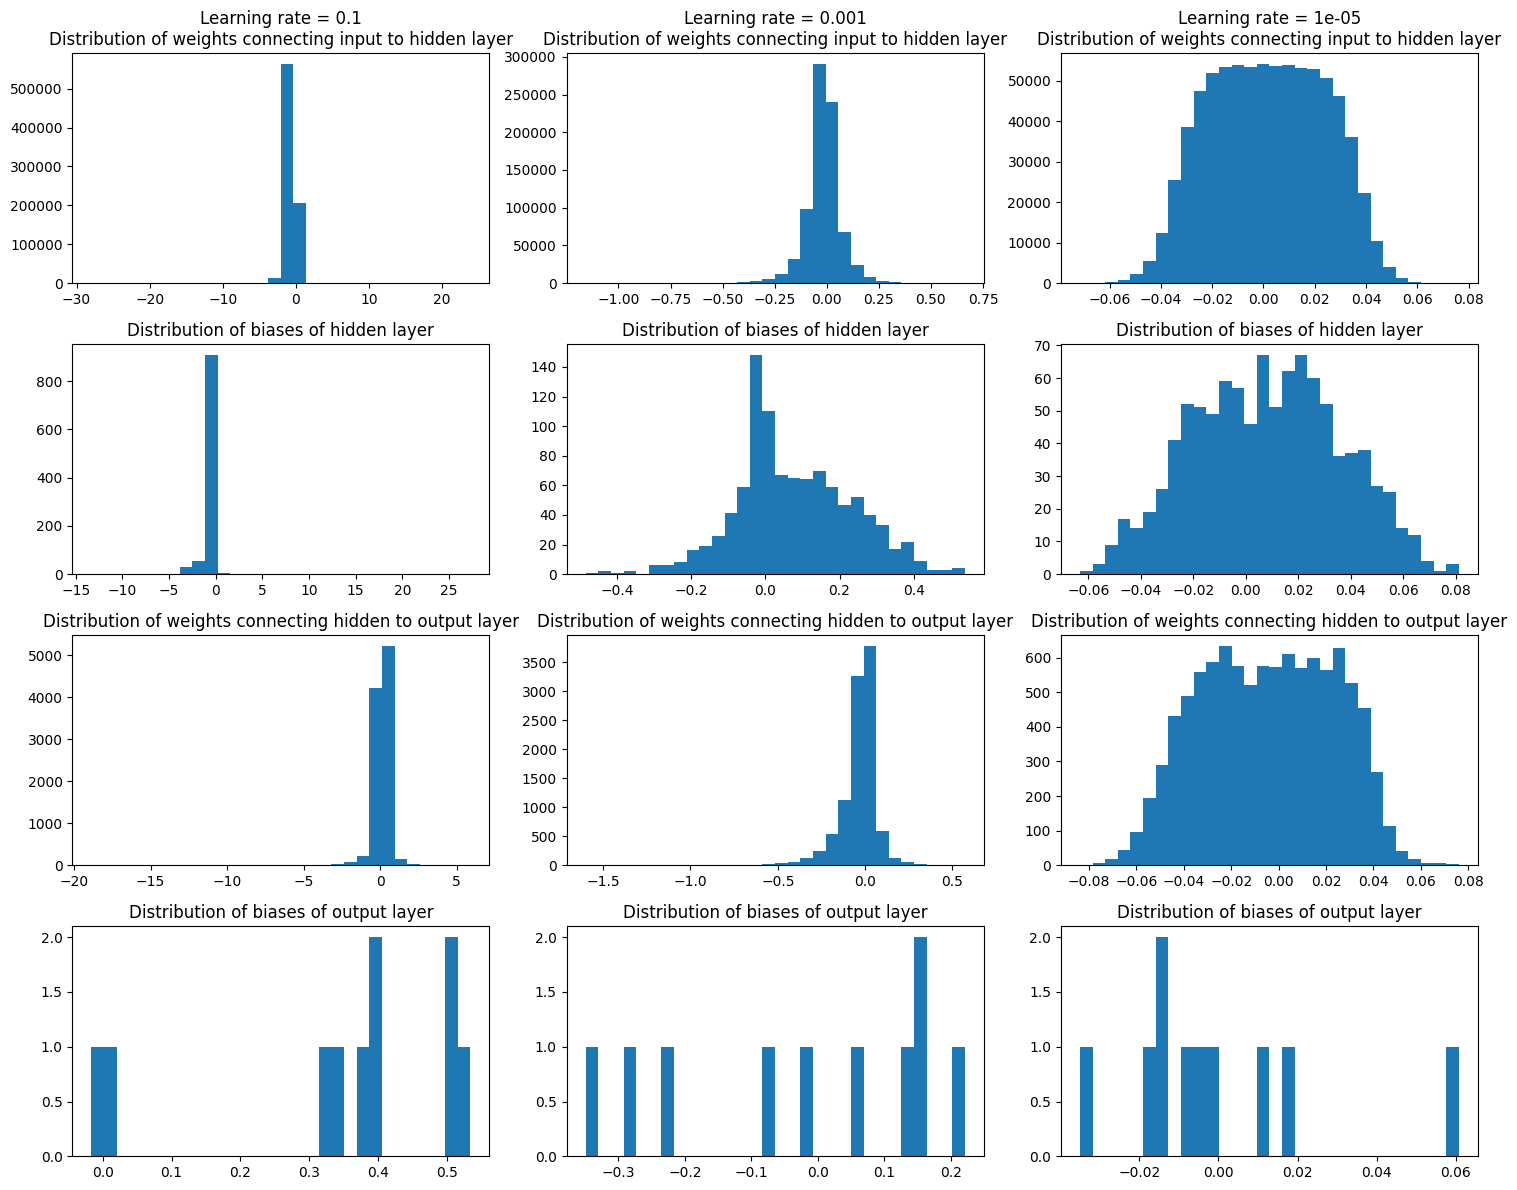

In [20]:
# ============================================================
# VẼ HISTOGRAM PHÂN PHỐI TRỌNG SỐ
# ============================================================

models = [model_lr_01, model_lr_0001, model_lr_000001]
learning_rates = [0.1, 0.001, 0.00001]

plt.figure(figsize=(15, 12))

for col, model in enumerate(models):
    lr = learning_rates[col]

    w1 = model[0].weight.detach().cpu().numpy().flatten()
    b1 = model[0].bias.detach().cpu().numpy().flatten()

    w2 = model[2].weight.detach().cpu().numpy().flatten()
    b2 = model[2].bias.detach().cpu().numpy().flatten()

    plt.subplot(4, 3, col + 1)
    plt.hist(w1, bins=30)
    plt.title(f"Learning rate = {lr}\nDistribution of weights connecting input to hidden layer")

    plt.subplot(4, 3, col + 4)
    plt.hist(b1, bins=30)
    plt.title("Distribution of biases of hidden layer")

    plt.subplot(4, 3, col + 7)
    plt.hist(w2, bins=30)
    plt.title("Distribution of weights connecting hidden to output layer")

    plt.subplot(4, 3, col + 10)
    plt.hist(b2, bins=30)
    plt.title("Distribution of biases of output layer")

plt.tight_layout()
plt.show()

In [21]:
# ============================================================
# TÁC ĐỘNG CỦA TỐC ĐỘ HỌC TRÊN DỮ LIỆU KHÔNG CHIA /255
# ============================================================

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

data_folder = "./data/FMNIST"

fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)
val_images = val_fmnist.data
val_targets = val_fmnist.targets


# Dataset KHÔNG chia cho 255
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28 * 28)
        self.x = x
        self.y = y

    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device)

    def __len__(self):
        return len(self.x)


def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)

    val = FMNISTDataset(val_images, val_targets)
    val_dl = DataLoader(val, batch_size=len(val_images), shuffle=False)

    return trn_dl, val_dl


def get_model(lr):
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)

    return model, loss_fn, optimizer


def train_batch(x, y, model, optimizer, loss_fn):
    model.train()

    prediction = model(x)
    batch_loss = loss_fn(prediction, y)

    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    model.eval()

    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y

    return is_correct.cpu().numpy().tolist()


@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()

    prediction = model(x)
    validation_loss = loss_fn(prediction, y)

    return validation_loss.item()


def run_lr_experiment(lr, epochs_count=5):
    trn_dl, val_dl = get_data()
    model, loss_fn, optimizer = get_model(lr)

    train_losses, train_accuracies = [], []
    val_losses, val_accuracies = [], []

    for epoch in range(epochs_count):
        print("Learning rate:", lr, "- Epoch:", epoch)

        train_epoch_losses, train_epoch_accuracies = [], []

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            batch_loss = train_batch(x, y, model, optimizer, loss_fn)
            train_epoch_losses.append(batch_loss)

        train_epoch_loss = np.array(train_epoch_losses).mean()

        for ix, batch in enumerate(iter(trn_dl)):
            x, y = batch
            is_correct = accuracy(x, y, model)
            train_epoch_accuracies.extend(is_correct)

        train_epoch_accuracy = np.mean(train_epoch_accuracies)

        for ix, batch in enumerate(iter(val_dl)):
            x, y = batch
            val_is_correct = accuracy(x, y, model)
            validation_loss = val_loss(x, y, model, loss_fn)

        val_epoch_accuracy = np.mean(val_is_correct)

        train_losses.append(train_epoch_loss)
        train_accuracies.append(train_epoch_accuracy)
        val_losses.append(validation_loss)
        val_accuracies.append(val_epoch_accuracy)

    return model, train_losses, train_accuracies, val_losses, val_accuracies

Device: cpu


100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.00MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 31.6MB/s]


Learning rate: 0.1 - Epoch: 0
Learning rate: 0.1 - Epoch: 1
Learning rate: 0.1 - Epoch: 2
Learning rate: 0.1 - Epoch: 3
Learning rate: 0.1 - Epoch: 4


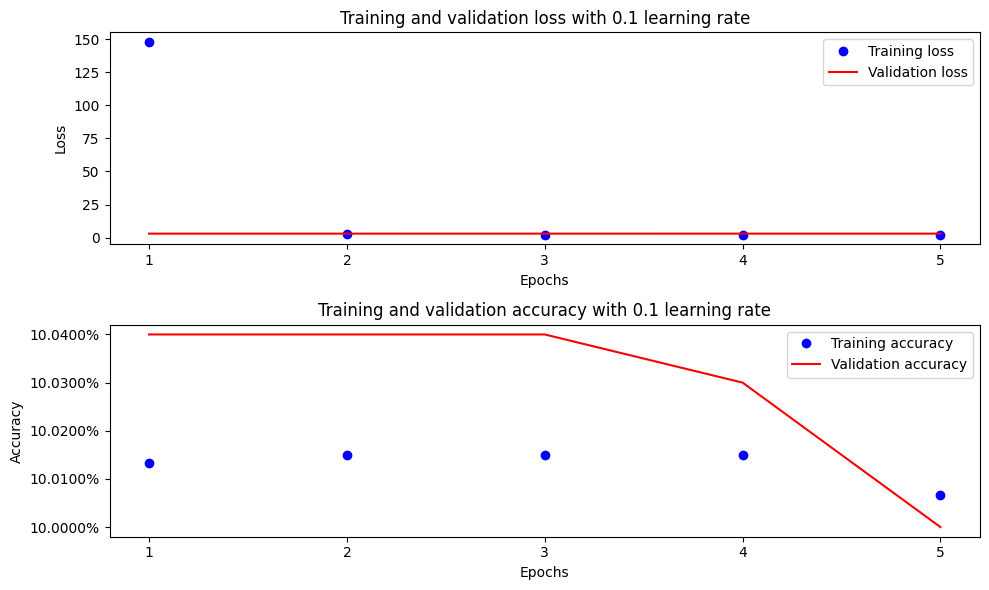

In [22]:
# ============================================================
# KHÔNG CHIA /255 - LEARNING RATE = 0.1
# ============================================================

model_no_scale_01, train_losses, train_accuracies, val_losses, val_accuracies = run_lr_experiment(
    lr=1e-1,
    epochs_count=5
)

epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss with 0.1 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy with 0.1 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

Learning rate: 0.001 - Epoch: 0
Learning rate: 0.001 - Epoch: 1
Learning rate: 0.001 - Epoch: 2
Learning rate: 0.001 - Epoch: 3
Learning rate: 0.001 - Epoch: 4


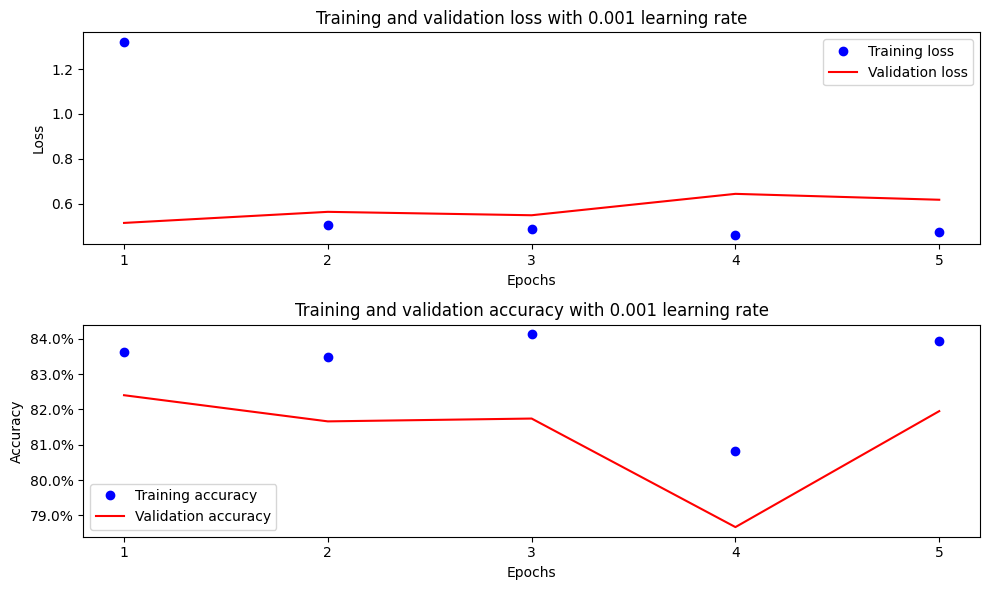

In [23]:
# ============================================================
# KHÔNG CHIA /255 - LEARNING RATE = 0.001
# ============================================================

model_no_scale_0001, train_losses, train_accuracies, val_losses, val_accuracies = run_lr_experiment(
    lr=1e-3,
    epochs_count=5
)

epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss with 0.001 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy with 0.001 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

Learning rate: 1e-05 - Epoch: 0
Learning rate: 1e-05 - Epoch: 1
Learning rate: 1e-05 - Epoch: 2
Learning rate: 1e-05 - Epoch: 3
Learning rate: 1e-05 - Epoch: 4


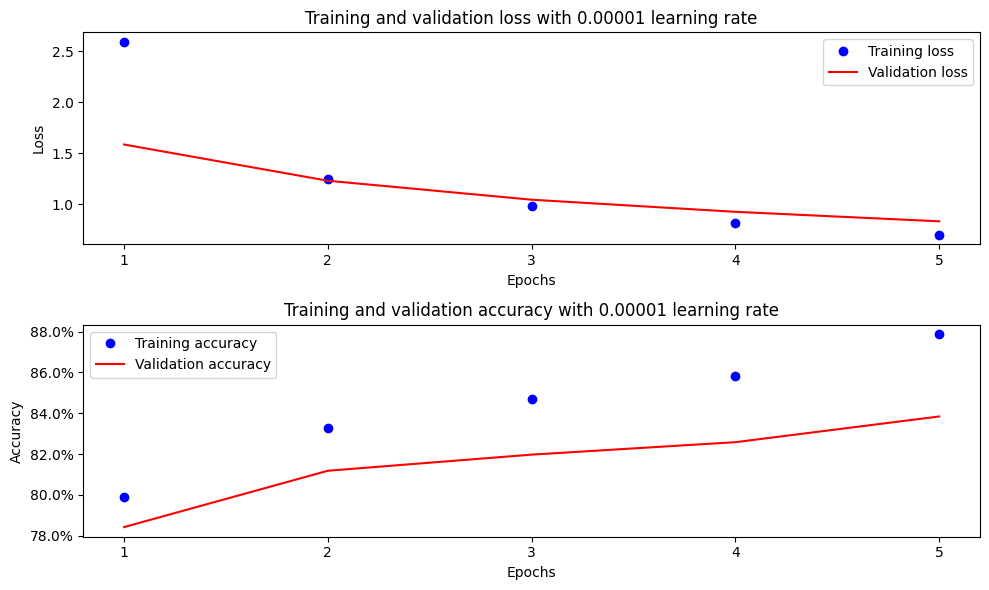

In [24]:
# ============================================================
# KHÔNG CHIA /255 - LEARNING RATE = 0.00001
# ============================================================

model_no_scale_000001, train_losses, train_accuracies, val_losses, val_accuracies = run_lr_experiment(
    lr=1e-5,
    epochs_count=5
)

epochs = np.arange(5) + 1

plt.figure(figsize=(10, 6))

plt.subplot(211)
plt.plot(epochs, train_losses, "bo", label="Training loss")
plt.plot(epochs, val_losses, "r", label="Validation loss")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation loss with 0.00001 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(False)

plt.subplot(212)
plt.plot(epochs, train_accuracies, "bo", label="Training accuracy")
plt.plot(epochs, val_accuracies, "r", label="Validation accuracy")
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title("Training and validation accuracy with 0.00001 learning rate")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()

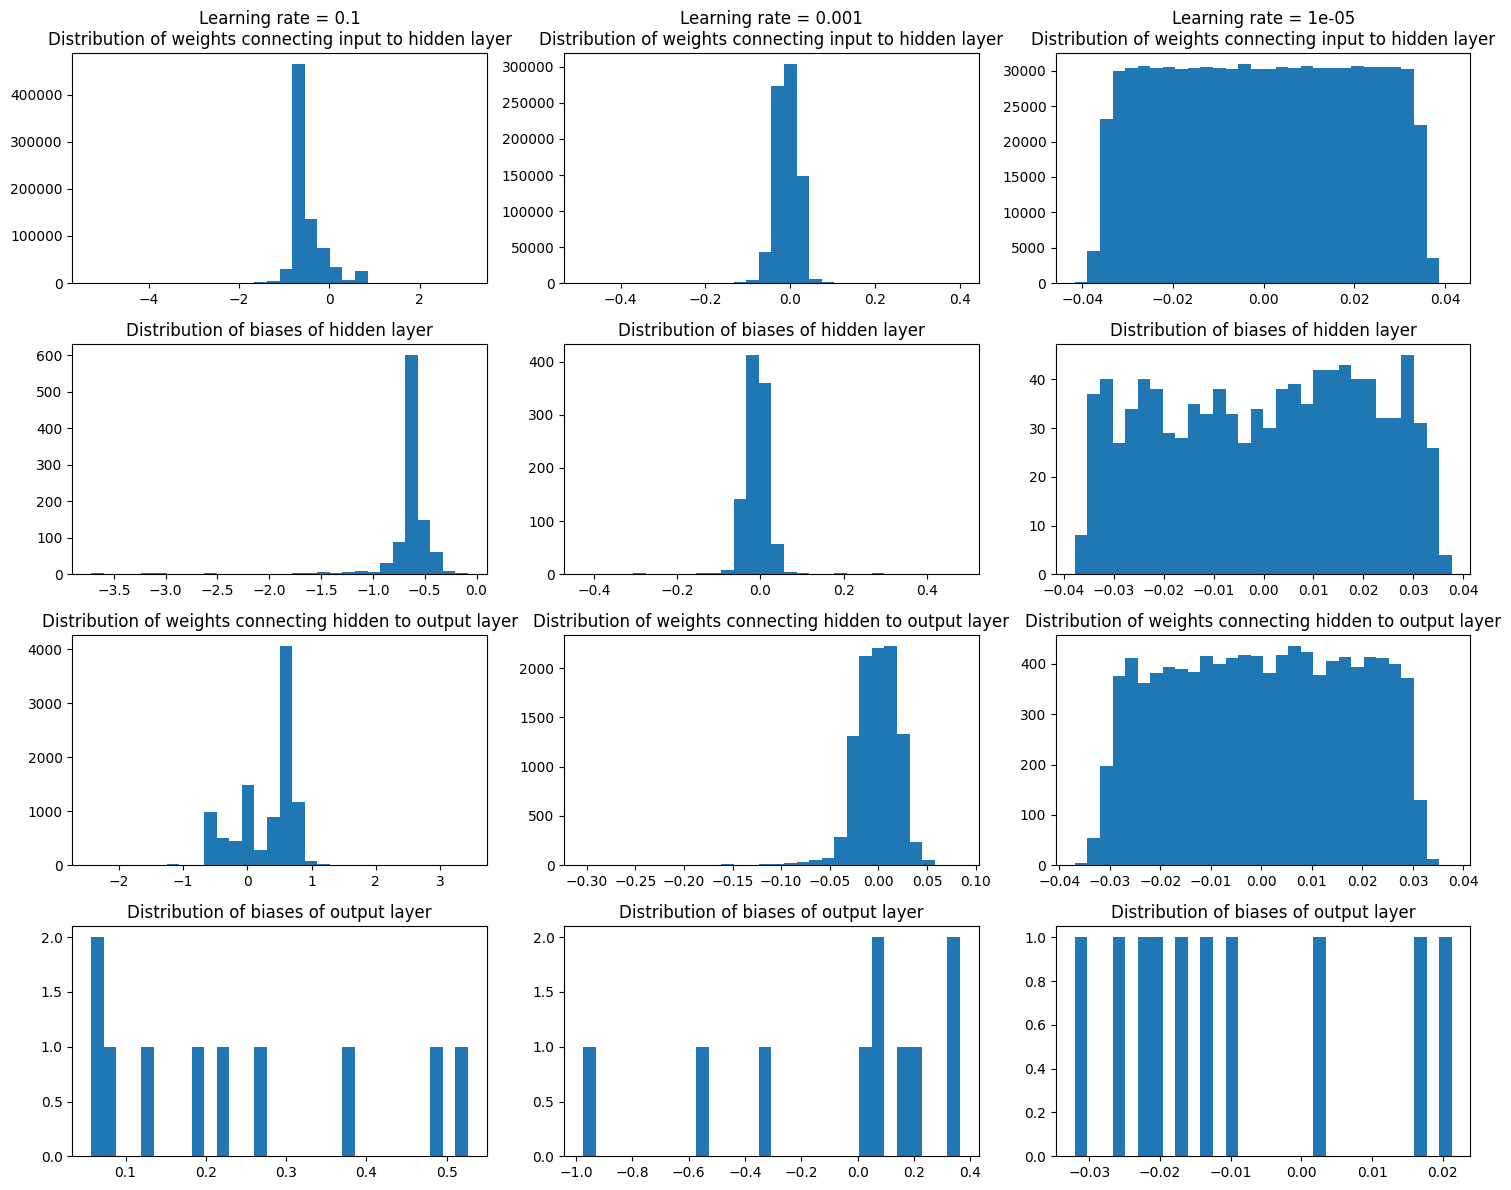

In [25]:
# ============================================================
# PHÂN PHỐI TRỌNG SỐ - DỮ LIỆU KHÔNG CHIA /255
# ============================================================

models = [
    model_no_scale_01,
    model_no_scale_0001,
    model_no_scale_000001
]

learning_rates = [
    0.1,
    0.001,
    0.00001
]

plt.figure(figsize=(15, 12))

for col, model in enumerate(models):
    lr = learning_rates[col]

    w1 = model[0].weight.detach().cpu().numpy().flatten()
    b1 = model[0].bias.detach().cpu().numpy().flatten()
    w2 = model[2].weight.detach().cpu().numpy().flatten()
    b2 = model[2].bias.detach().cpu().numpy().flatten()

    plt.subplot(4, 3, col + 1)
    plt.hist(w1, bins=30)
    plt.title(f"Learning rate = {lr}\nDistribution of weights connecting input to hidden layer")

    plt.subplot(4, 3, col + 4)
    plt.hist(b1, bins=30)
    plt.title("Distribution of biases of hidden layer")

    plt.subplot(4, 3, col + 7)
    plt.hist(w2, bins=30)
    plt.title("Distribution of weights connecting hidden to output layer")

    plt.subplot(4, 3, col + 10)
    plt.hist(b2, bins=30)
    plt.title("Distribution of biases of output layer")

plt.tight_layout()
plt.show()